In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
from torchvision import models

model = models.squeezenet1_1(pretrained=True)
print(model)

/data/wilson/seeing-is-believing/venvs/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/wilson/seeing-is-believing/venvs/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /users/Marthen/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 107MB/s]

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): MaxPool2d

In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)
print(project_root)

/data/wilson/seeing-is-believing


In [3]:
# Environment variables
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1, 2, 3"

In [4]:
import pandas as pd

df = pd.read_csv("../ISIC2018_Task3_Training_Input/cleaned_data.csv")

In [5]:
file_path = "/data/dataset/ISIC2018_Task3_Training_Input"
unique_labels = df['label'].unique()
label_map = {label: idx for idx, label in enumerate(unique_labels)}

In [ ]:
# from utils.statistics import RunningStatsCalculator
# from tqdm import tqdm

# stats_cal = RunningStatsCalculator()

# for images, _ in tqdm(dataloader, desc="Calculating Stats"):
#     stats_cal.update(images)

In [6]:
# Augmentation pipeline
from torchvision import transforms
from torchvision.transforms import functional as F
import random
from utils.transforms import ShadesOfGrayTransform

MODEL_INPUT_SIZE = 224

RESIZE_SIZE = int(MODEL_INPUT_SIZE * 1.25)

data_transform_train = transforms.Compose([
    transforms.ToTensor(),
    ShadesOfGrayTransform(),
    transforms.Resize(RESIZE_SIZE), # resize all images 
    transforms.RandomResizedCrop(MODEL_INPUT_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda img: F.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.Normalize(mean=[0.7635, 0.5461, 0.5705], std=[0.1412, 0.1529, 0.1703]) 
])

2025-11-11 20:50:56.842404: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [21]:
data_transform_val = transforms.Compose([
    transforms.ToTensor(),
    ShadesOfGrayTransform(),
    transforms.Resize(MODEL_INPUT_SIZE),
    transforms.Normalize(mean=[0.7635, 0.5461, 0.5705], std=[0.1412, 0.1529, 0.1703])
])

In [27]:
from utils.dataset import ImageDataset
from torch.utils.data import DataLoader

train_dataset = ImageDataset(
    df=df,
    file_path=file_path,
    transform=data_transform_train,
    label_map=label_map
)

val_dataset = ImageDataset(
    df=df,
    file_path=file_path,
    transform=data_transform_val,
    label_map=label_map
)

In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset
from base import Trainer
from transformers import ResNetForImageClassification
import torch.optim as optim
import torch.nn as nn
import torch

k_folds = 5
histories = []
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
for fold_index, (train_indices, val_indices) in enumerate(skf.split(df, df['label'].values)):
    print(f"--- FOLD {fold_index + 1}/{k_folds} ---")

    train_subset = Subset(train_dataset, train_indices)
    val_subset = Subset(val_dataset, val_indices)

    train_loader = DataLoader(
        train_subset,
        batch_size = 64,
        shuffle=True,
        num_workers = 4
    )

    val_loader = DataLoader(
        val_subset,
        batch_size = 64,
        shuffle = False,
        num_workers = 4
    )

    model = ResNetForImageClassification.from_pretrained("microsoft/resnet-18", num_labels=10, ignore_mismatched_sizes=True).to("cuda:1")

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    epochs = 10
    patience = 10
    min_delta = 0.0

    trainer = Trainer(
        model=model,
        model_name="resnet-18",
        optimizer=optimizer,
        criterion=criterion, 
        train_loader = train_loader,
        val_loader = val_loader,
        device = "cuda:1",
        epoch = epochs,
        patience = patience,
        min_delta=min_delta,
        early_stopping=True,
    )

    history = trainer.run()
    histories.append(history)

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([10, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- FOLD 1/5 ---


Validation: 100%|██████████| 32/32 [00:06<00:00,  4.59it/s]
Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([10, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- FOLD 2/5 ---


Validation: 100%|██████████| 32/32 [00:06<00:00,  4.67it/s]


...

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([10, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Validation: 100%|██████████| 32/32 [00:06<00:00,  4.71it/s]
Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([10, 512]) in the model 

--- FOLD 4/5 ---


Validation: 100%|██████████| 32/32 [00:06<00:00,  4.66it/s]


--- FOLD 5/5 ---


Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([10, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Validation: 100%|██████████| 32/32 [00:06<00:00,  4.67it/s]


In [37]:
histories

[{'training_loss': [0.8308303334883281,
   0.7036354676598594,
   0.6301206880145602,
   0.5971489988622212,
   0.5809655629453205,
   0.534961880909072,
   0.5436254874581382,
   0.5105338311857648,
   0.49482791125774384,
   0.49365867189471685],
  'training_accuracy': [71.21817274088866,
   74.20119820269596,
   76.58512231652522,
   78.00798801797303,
   78.79430853719421,
   80.54168746879681,
   79.94258612081877,
   81.19071392910634,
   82.30154767848228,
   82.36395406889666],
  'val_loss': [0.7364967777393758,
   0.6449512108229101,
   0.6270648357458413,
   0.7132090285886079,
   0.6396376579068601,
   0.8468370134942234,
   0.5686663573142141,
   0.6533711322117597,
   0.7179332673549652,
   0.6518726418726146],
  'val_accuracy': [75.23714428357464,
   76.73489765351972,
   76.2855716425362,
   74.6380429355966,
   77.73339990014978,
   72.5411882176735,
   79.78032950574139,
   75.88617074388418,
   74.48826759860209,
   78.0329505741388]},
 {'training_loss': [0.8173952495

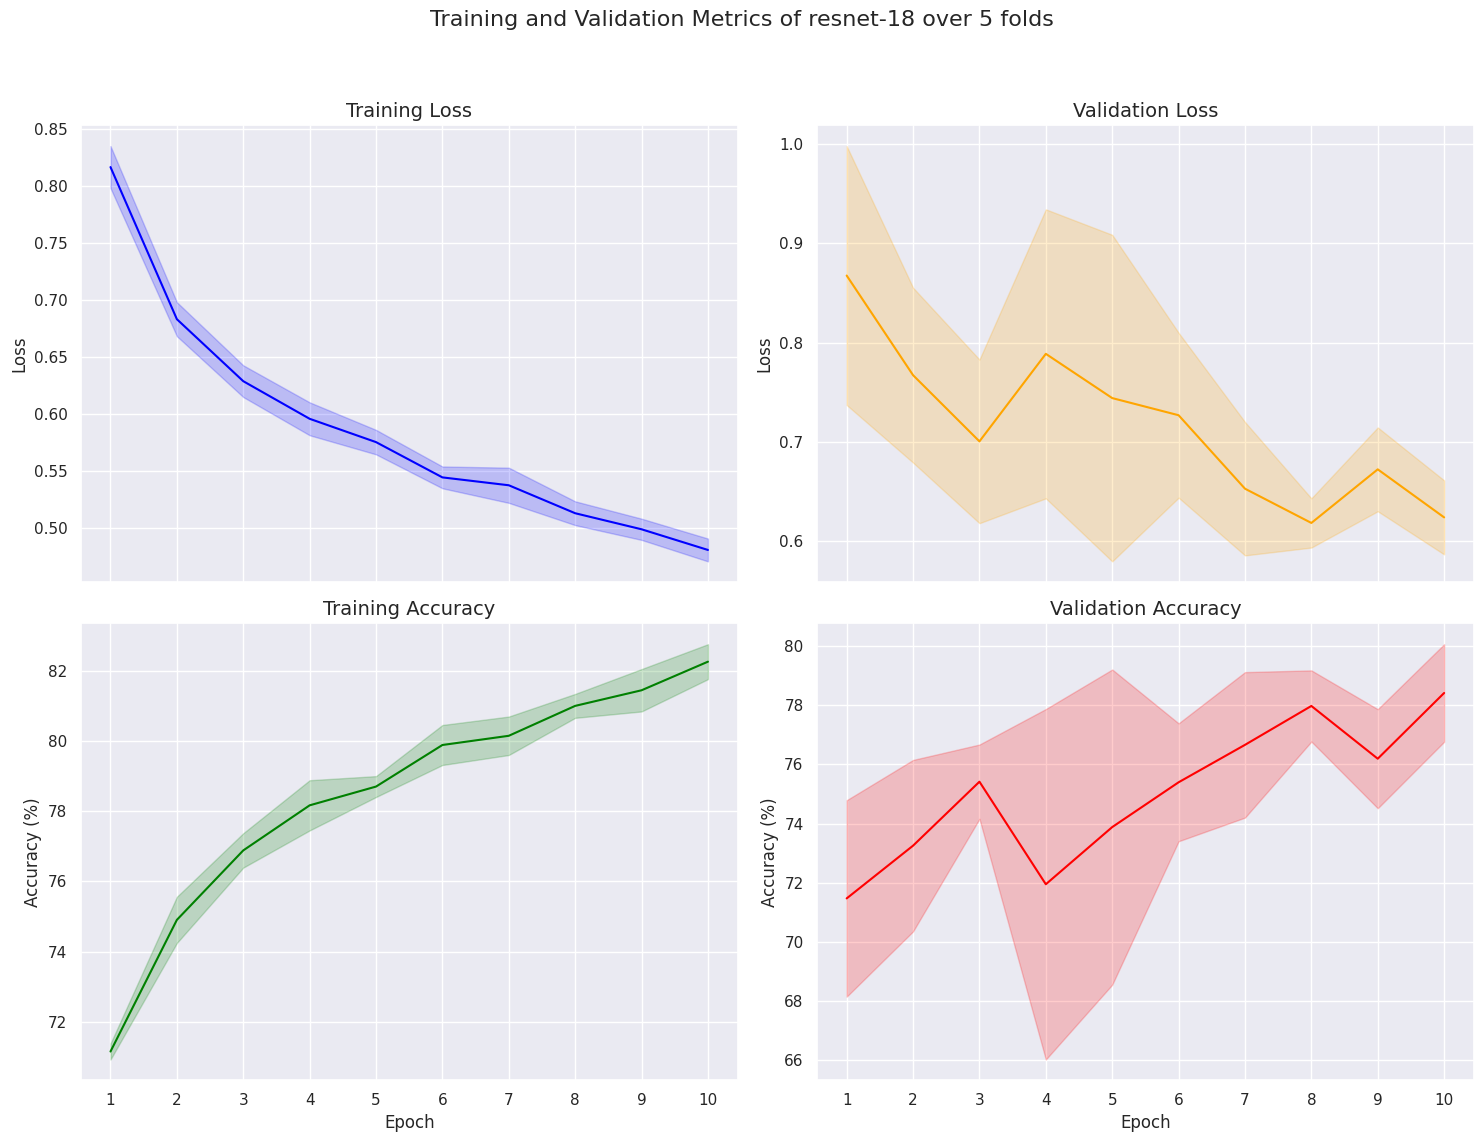

In [10]:
from helpers.plotting import plot_metrics

histories = [{'training_loss': [0.8308303334883281,0.7036354676598594,0.6301206880145602,0.5971489988622212,0.5809655629453205,0.534961880909072,0.5436254874581382,0.5105338311857648,0.49482791125774384,0.49365867189471685], 
         'training_accuracy': [71.21817274088866,74.20119820269596,76.58512231652522,78.00798801797303,78.79430853719421,80.54168746879681,79.94258612081877,81.19071392910634,82.30154767848228,82.36395406889666], 
         'val_loss': [0.7364967777393758,0.6449512108229101,0.6270648357458413,0.7132090285886079,0.6396376579068601,0.8468370134942234,0.5686663573142141,0.6533711322117597,0.7179332673549652,0.6518726418726146], 
         'val_accuracy': [75.23714428357464,76.73489765351972,76.2855716425362,74.6380429355966,77.73339990014978,72.5411882176735,79.78032950574139,75.88617074388418,74.48826759860209,78.0329505741388]}, 
         {'training_loss': [0.8173952495294904,0.6636697127232476,0.6186339344297137,0.5965631126411377,0.570989012245148,0.5421863288160355,0.5300911142239495,0.5199140166006391,0.5046733804638424,0.4842484449110334], 
          'training_accuracy': [70.90614078881677,75.91113330004993,77.58362456315527,78.0329505741388,78.9565651522716,80.14228657014478,80.32950574138792,81.02845731402896,80.65401897154268,82.05192211682477], 
          'val_loss': [1.051135326270014,0.770230676047504,0.717565624974668,0.8905676901340485,0.615599658805877,0.7164463538210839,0.6405607184860855,0.6193908599670976,0.696793919429183,0.566969302482903], 
          'val_accuracy': [66.74987518721917,73.43984023964055,75.53669495756365,67.54867698452321,76.73489765351972,74.73789316025962,76.78482276585122,78.0329505741388,74.58811782326511,79.73040439340988]}, 
          {'training_loss': [0.8093784903250043,0.6840387083708294,0.6304500372636885,0.6170148087872399,0.5820867897026123,0.5426914831475605,0.5483292040843812,0.5146194105110471,0.5121425915332067,0.47867575216860997], 
           'training_accuracy': [71.46779830254619,74.76285571642536,76.95956065901149,77.27159261108338,78.27009485771343,79.91762356465303,79.79281078382427,81.14078881677484,81.34048926610085,81.93959061407888], 
           'val_loss': [0.7877795668318868,0.8697731494903564,0.6225818765815347,0.9934737589210272,0.7876198019366711,0.7655014402698725,0.7404637299478054,0.6295502241700888,0.6717010403517634,0.6203041183762252], 
           'val_accuracy': [73.09036445332002,68.84672990514228,76.53519720419371,63.854218671992015,74.6380429355966,75.13729405891164,74.5381927109336,78.68197703444832,76.23564653020469,78.93160259610585]}, 
           {'training_loss': [0.7892566940614155,0.6756855171351206,0.6146474899280638,0.5767190075582929,0.5586441318903651,0.5422740791525159,0.5143719649031049,0.49685213513790616,0.4885806791366093,0.46610310011439854], 
            'training_accuracy': [71.24313529705442,75.13729405891164,77.00948577134298,79.25611582626061,78.9565651522716,79.83025461807289,81.01597603594608,81.22815776335497,81.66500249625561,83.07538691962057], 
            'val_loss': [0.8097490258514881,0.724295903230086,0.8239390898961574,0.6818589624017477,1.0134363258257508,0.634009036468342,0.6188315986655653,0.600794542580843,0.6709486765321344,0.6195547891547903], 
            'val_accuracy': [72.690963554668,74.58811782326511,73.33999001497753,76.08587119321018,64.55317024463305,77.58362456315527,78.2825761357963,78.58212680978532,78.2825761357963,79.68047928107838]}, 
            {'training_loss': [0.8353139266135201,0.6887150276747961,0.6503458673518802,0.5919933285978105,0.5845703645831063,0.5606263523537015,0.5518108171129984,0.5238116996155845,0.49515689767542337,0.48214310833386015], 
             'training_accuracy': [70.96854717923115,74.52571143285073,76.2855716425362,78.27009485771343,78.53220169745381,78.99400898652021,79.65551672491263,80.40439340988517,81.25312031952072,81.85222166749875], 
             'val_loss': [0.9532921565696597,0.8278020115103567,0.7127595408819616,0.6653339085169137,0.6654307206626981,0.6726458256598562,0.6971851484850049,0.5901737618260086,0.6057179956696928,0.6625928664579988], 
             'val_accuracy': [69.54568147778332,72.6410384423365,75.38691962056915,77.58362456315527,75.73639540688967,76.98452321517723,73.93909136295557,78.73190214677983,77.38392411382925,75.73639540688967]}]

plot_metrics(histories, model_name="resnet-18", save_path="results/resnet18_task3_metrics.pdf")

In [ ]:
# Augmentation pipeline
from torchvision import transforms
from torchvision.transforms import functional as F
import random
from utils.transforms import ShadesOfGrayTransform

MODEL_INPUT_SIZE = 1.25 * 224

RESIZE_SIZE = int(MODEL_INPUT_SIZE * 1.25)

data_transform_train = transforms.Compose([
    transforms.ToTensor(),
    ShadesOfGrayTransform(),
    transforms.Resize(RESIZE_SIZE), # resize all images 
    transforms.RandomResizedCrop(MODEL_INPUT_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda img: F.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    # ImageNet (Left with this)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [5]:
df.shape

(10015, 2)

In [6]:
df.columns

Index(['image', 'label'], dtype='object')

In [7]:
df['label'].value_counts()

label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64

In [8]:
from sklearn.model_selection import StratifiedKFold

X = df['image']
y = df['label']

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)